----
# Kolokwium 1
----

In [81]:
%matplotlib inline
import sympy 
import numpy as np
import scipy
import matplotlib.pyplot as plt 


----
## Zadanie 0
---- 
Proszę przypisać wartości zmiennych
- imie_i_nazwisko,
- numer_indeksu,
- numer_grupy_lab,
- X *(podane przez prowadzącego)*,


oraz obliczyć wartość zmiennej *K*

In [82]:
imie_i_nazwisko = "Hubert Fronczek"

N = (153863 * 13) % 6
print(N)

5


----
## Zadanie 1. Określanie wzorów funkcji i wartosci funkcji
----
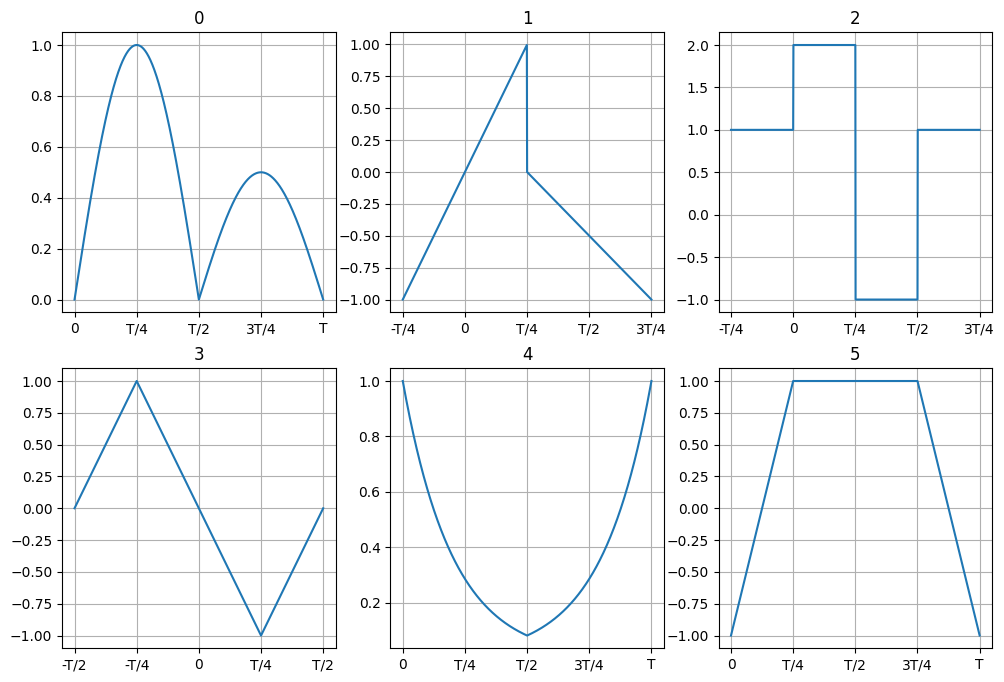

Proszę zdefiniować wzór funkcji numer `N` w odpowiednim przedziale, uzależniając go od symbolu `T` (`sympy.Piecewise`)

Proszę zdefiniować wektor czasów dla danego przedziału (składający się z przynajmniej 200 elementów) oraz wyliczyć wektor próbek funkcji w tym przedziale (`sympy.lambdify`). Początkowo za `T` proszę przyjąć 1.

Proszę wykreślić przebieg funkcji na wykresie (`matlplotlib`). Proszę opisać osie wykresu.

Ostatecznie za `T` proszę podstawić sumę cyfr swojego numeru indeksu i ponownie uruchomić skrypt.

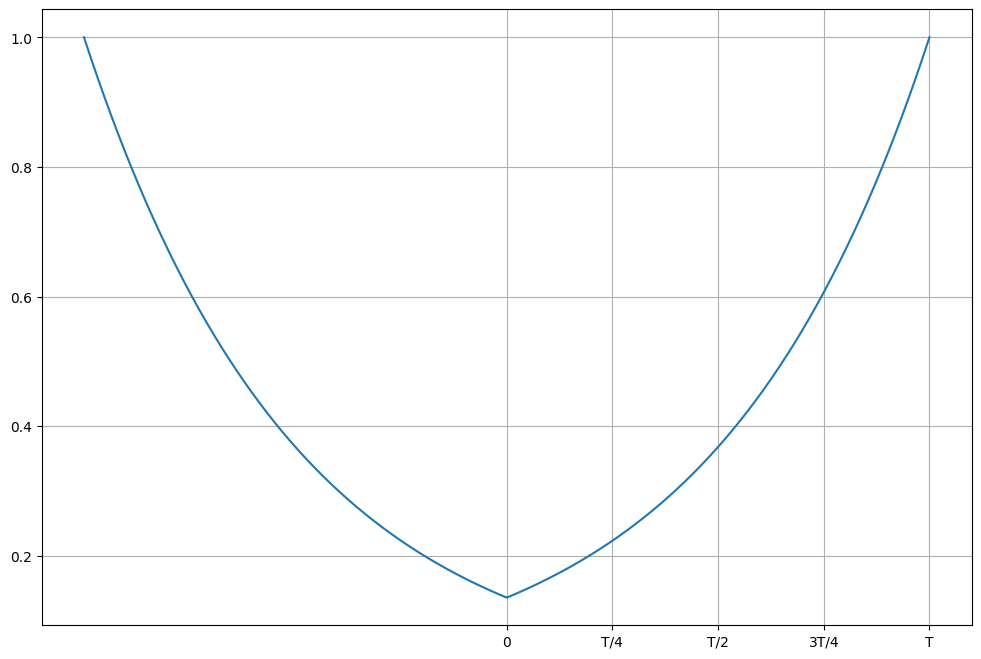

In [ ]:
import sympy 
import numpy as np
import matplotlib.pyplot as plt 

#declare symbolic variable t (time) and period (T=1)
t = sympy.Symbol('t', real = 'True', nonzero = 'True') 
plt.rcParams['figure.figsize']=(12, 8)

NumberOfSamples = 1001
A = 1 
T = 1
fa = ((4*T)/A) * t
fb = A
fc = ((-4 * A)/T) * t + T + 3*A



fd = sympy.Piecewise((1, (t>= -T/4)&(t < 0)), (2, (t >=0)&(t < T/4)), (-1, (t>=T/4)&(t < T/2)), (1, (t >= T/2)&(t < 3*T/4)), (0 , True))
# N5 = sympy.lambdify(t, sympy.Piecewise((np.e**((-t-1)*2), t<0), (np.e**((t-1)*2), t>0)), 'numpy')

# fd = sympy.Piecewise((fa, (t>=0 ) & ( t <=T/4)) , (fb, (t >T/4) & (t <= (3/4)*T)), (fc, (t > (3/4)*T) & (t<=T)))
fd_num = sympy.lambdify(t, fd)
x = np.linspace(-T,T,NumberOfSamples)
plt.plot(x, fd_num(x))
plt.xticks(
    [0, T/4, T/2, 3*T/4, T],
    ["0", "T/4", "T/2", "3T/4", "T"]
)
# plt.yticks([A,3*A/4,A/2,A/4],["A","3A/4","A/2","A/4"])
plt.grid()
plt.show()

currFun = fd



----
## Zadanie 2. Wyznaczanie współczynników szeregu Fouriera (analityczne)
----

$$ f(t) = \sum_{k=-\infty}^{\infty} F_k e^{j k {{2 \pi } \over T } t} \text{   for:   } k \in \mathbb{C} $$ 

$$ F_0 = { 1 \over T } \int\limits_{-{T \over 2}}^{{T \over 2}}f(t)dt  $$

$$ F_k = { 1 \over T } \int\limits_{-{T \over 2}}^{{T \over 2}} f(t) e^{-jkt {2\pi \over T}} dt \text{   for:   } k \in \mathbb{C}, k \neq 0 $$

Na podstawie powyższych wzorów proszę zdefiniować funkcję obliczjącą współczynniki szeregu Fouriera w postaci symbolicznej (`sympy`).
Podpowieź: przydatne funkcje `sympy.exp`, `sympy.simplify`, `sympy.integrate`

Wykorzystując zdefiniowwaną funkcję proszę obliczyć i wyświetlić wyrażenia na współczynniki szeregu Fouriera dla funkcji z poprzedniego zadania.

Proszę wyznaczyć implementację numeryczną wyrażenia na współczynniki szeregu Fouriera, wyliczyć i wyświetlić wartości współczynników o indeksach od `-N-5` do `N+5` włącznie. 

Proszę wyliczyć i przedstawić na wykresach prążkowych (`plt.stem`) amplitudy i fazy wyliczonych współczynników.

*Dla wybitnych:* Proszę dowolnym sposobem wyznaczyć i narysować rekonstrukcję sygnału na podstawie wyżej wyznaczonych współczynników (od `-N-5` do `N+5` włacznie) 

0.500000000000000

-0.5*(-1)**(k + 1/2)/(pi*k) - 0.5*I*exp(0.5*I*pi*k)/(pi*k) - 0.5*I/(pi*k) + 1.5*I*exp(-0.5*I*pi*k)/(pi*k)

/tmp/ipykernel_14448/1855430245.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


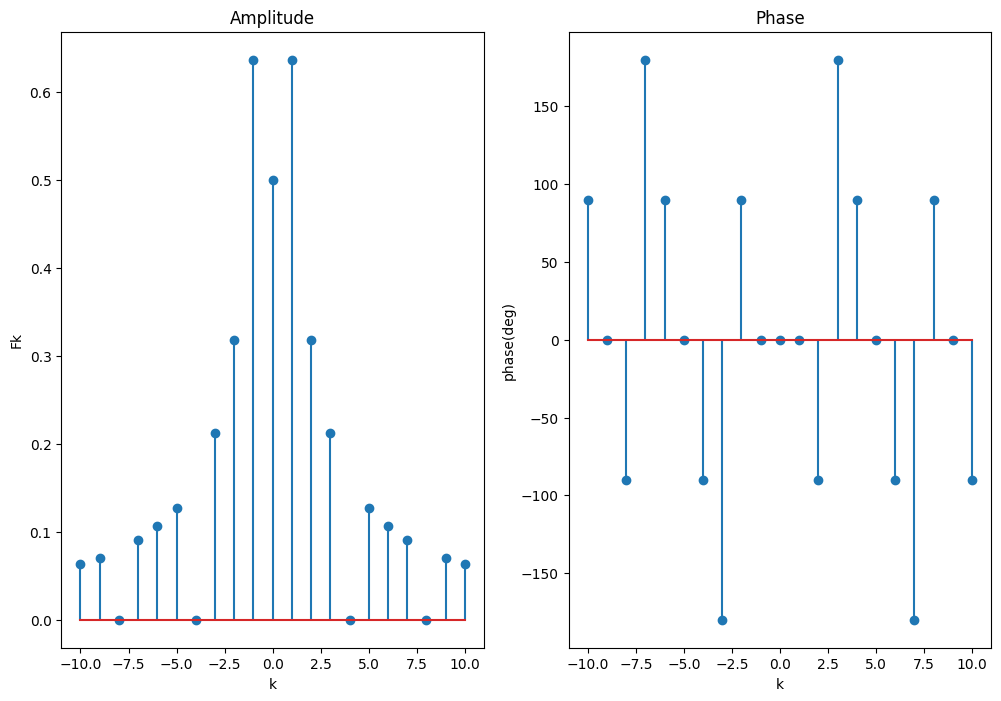

In [84]:
k = sympy.Symbol('k', real = 'True', nonzero=True, positive=True, integer=True)
from sympy import I, pi, exp, integrate, simplify

def oblicz_wspolczynniki_szeregu(funkcja, początek_zakresu, koniec_zakresu):
    F0, Fk = 0, 0
    #kernel
    exp_ = sympy.exp(-1j * k * t * (2*sympy.pi/T))
    F0 = 1/T * sympy.integrate(funkcja,(t,początek_zakresu,koniec_zakresu))
    Fk = 1/T * sympy.integrate(funkcja * exp_,(t,początek_zakresu,koniec_zakresu))
    return F0, Fk

F0, Fk = oblicz_wspolczynniki_szeregu(currFun,-T/2,T/2)
display(sympy.simplify(F0))
display(sympy.simplify(Fk))
k_values = np.arange(-N-5,N+6,1)
def oblicz_wartosci_wspolczynnikow(Fk, F0, N):
    k_values = np.arange(-N-5,N+6,1)
    Fk_vector = np.empty_like(k_values, dtype=complex)
    for i,kval in enumerate(k_values):
        if kval == 0:
            Fk_vector[i] = F0
        else:
            Fk_vector[i] = Fk.subs(k, kval)
    return Fk_vector

Fk_vector = oblicz_wartosci_wspolczynnikow(Fk,F0,N)

fig, ax = plt.subplots(1, 2)


ax[0].stem(k_values, abs(Fk_vector))
ax[0].set_title("Amplitude")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Fk")
ax[1].stem(k_values, np.angle(Fk_vector, deg=True))
ax[1].set_title("Phase")
ax[1].set_xlabel("k")
ax[1].set_ylabel("phase(deg)")
fig.show()

## Rekonstrukcja (dla wybitnych):


## Zadanie 3. Stabilność i minimalnofazowość

Proszę określić, czy układ o podanej transmitancji jest stabilny w sensie BIBO i minimalnofazowy.

$$
H(s) = \frac{s^6 + 5s^5 + 7s^4 + 2N s^3 + s^2 + 2}{s^2 + (0.5N + 1)s + 3}
$$

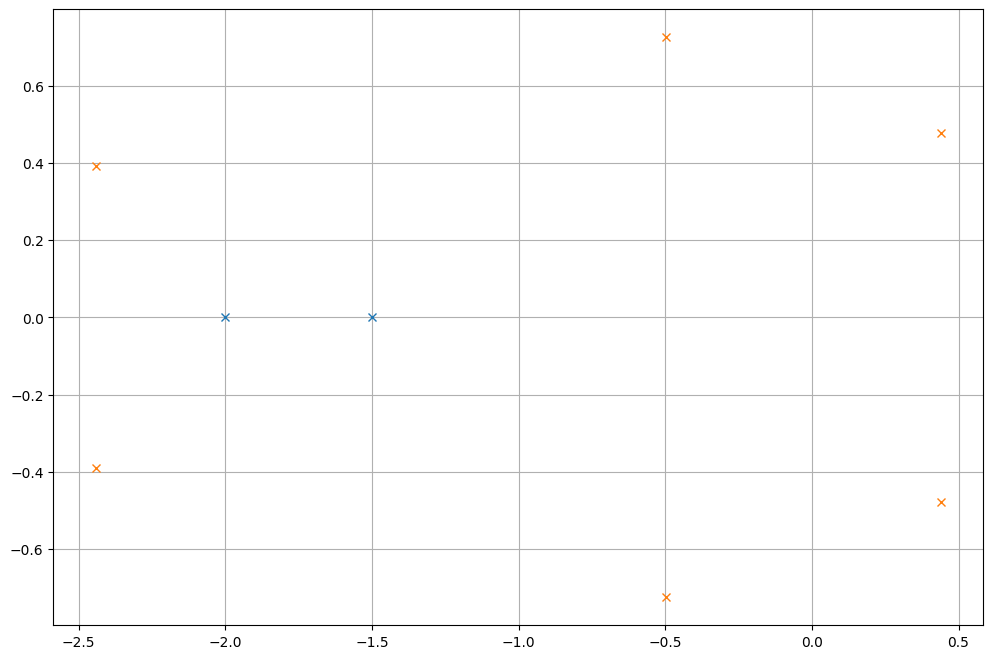

Układ jest stabilny w sensie BIBO
Układ nie jest minimalnofazowy


In [114]:

numerator = np.poly1d([1,5,7,2,1,0,2])
denominator = np.poly1d([1,(0.5*N + 1), 3])

poles = np.roots(denominator)
zeros = np.roots(numerator)

def ReIm(H):
    return np.real(H), np.imag(H)

poles_re , poles_im = ReIm(poles)
zeros_re , zeros_im = ReIm(zeros)

plt.plot(poles_re, poles_im, "x")
plt.plot(zeros_re, zeros_im, "x")
plt.grid()
plt.show()

def BIBO_stability(poles_re):
    for i in poles_re:
        if(i > 0):
            print("Układ nie jest stabilny w sensie BIBO")
            break
    print("Układ jest stabilny w sensie BIBO")

def minimum_phase(zeros_re):
    for i in zeros_re:
        if(i > 0):
            print("Układ nie jest minimalnofazowy")
            return
    print("Układ jest minimalnofazowy")

BIBO_stability(poles_re)
minimum_phase(zeros_re)


## Zadanie 4. Charakterystyki układów

---

Proszę wyznaczyć i wykreślić charakterystyki amplitudową oraz fazową układu o podanej transmitancji.

Proszę wyznaczyć i wykreślić odpowiedź impulsową tego układu.

Proszę pamiętać o opisie osi na wykresach.

$$
H(s) = \frac{s + N + 1}{(N + 2)s^2 + s + 1}
$$

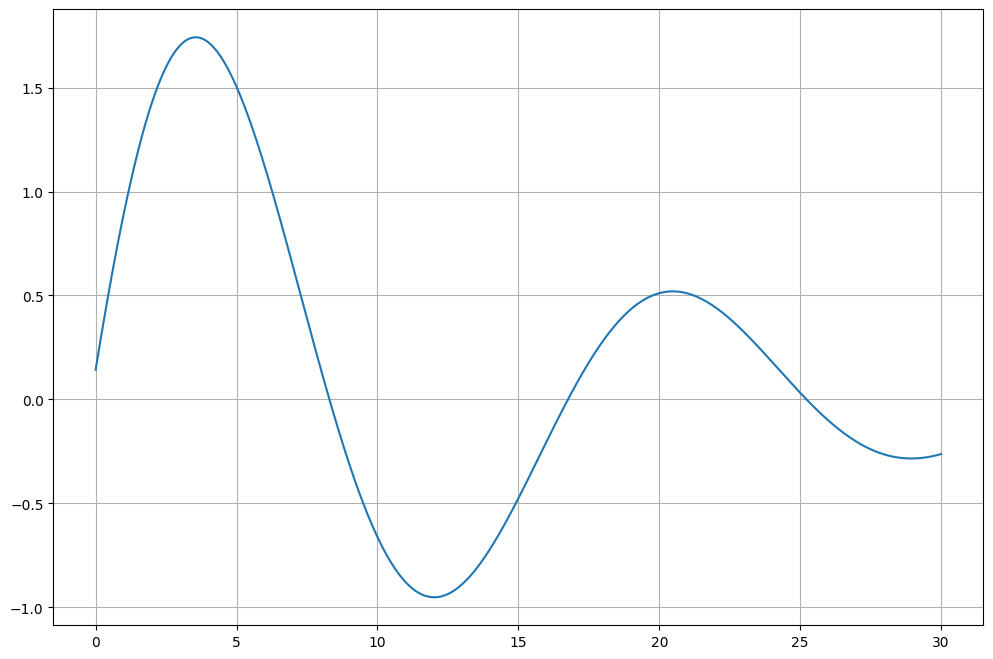

In [118]:
nominator = np.poly1d([1,(N+1)])
denominator = np.poly1d([(N+2), 1, 1 ])

#odpowiedz impulsowa


def calculateImpulseResponseFromNumDen(B, A, TimeDomain):
    step = scipy.signal.impulse(scipy.signal.tf2ss(B, A), T=TimeDomain)[1]
    return step
time = np.linspace(0,30,3000)
impulse = calculateImpulseResponseFromNumDen(nominator, denominator,time)

plt.plot(time,impulse)
plt.grid()
plt.show()



